**NOTICE:**  
The U.S. Army Corps of Engineers, Risk Management Center (USACE-RMC) makes no guarantees about the results, or appropriateness of outputs, obtained from Numerics.

# 03. MCMC Basics: Introduction to Bayesian Inference
This notebook introduces Markov Chain Monte Carlo (MCMC) for Bayesian inference using Numerics. Each sampler run is a small test that checks whether posterior samples recover known parameters on synthetic data.

## What You'll Learn

- What is MCMC and why use it...
- Setting up priors
- Defining likelihood functions
- Running the RWMH (Random Walk Metropolis-Hastings) sampler
- Interpreting results (trace plots, posterior distributions)
- Burn-in and thinning

## When to Use MCMC

MCMC is useful when:
- You want to quantify uncertainty in parameters
- You have prior knowledge to incorporate
- You need full posterior distributions, not just point estimates
- Standard optimization methods are insufficient

## Available MCMC Samplers
| Sampler | Full Name | Best For | Key Features |
|---------|-----------|----------|--------------|
| **RWMH** | Random Walk Metropolis-Hastings | General purpose, small dimensions | Simple, robust baseline |
| **ARWMH** | Adaptive Random Walk M-H | Medium dimensions (2-20) | Self-tuning proposal |
| **DEMCz** | Differential Evolution MCMC | High dimensions, multimodal | Population-based, efficient |
| **DEMCzs** | DE-MCMC with snooker update | Very high dimensions | Enhanced DE-MCMC |
| **HMC** | Hamiltonian Monte Carlo | Smooth posteriors | Uses gradient information |
| **NUTS** | No-U-Turn Sampler | General smooth posteriors | Auto-tuning HMC |
| **Gibbs** | Gibbs Sampler | Conditional distributions available | No rejections |

But for now we're only going to take a look at RWMH in this notebook. The rest are covered in notebook 04 and 05!

## Introduction to MCMC Fundamentals
Before using any specific sampler, it helps to understand the core theory that underpins all MCMC methods.

### Target Distribution

The goal of MCMC is to draw samples from a posterior distribution that is known only up to a normalizing constant. By Bayes' theorem, the posterior is proportional to the product of the prior and the likelihood:

```math
\pi(\theta \mid y) \propto \pi(\theta) \cdot L(y \mid \theta)
```

Taking the logarithm, which is how the Numerics library works internally:

```math
\log \pi(\theta \mid y) = \log \pi(\theta) + \log L(y \mid \theta) + \text{const}
```

The `LogLikelihoodFunction` delegate in Numerics should return the sum $\log \pi(\theta) + \log L(y \mid \theta)$, i.e., the unnormalized log-posterior.

### Detailed Balance

A Markov chain with transition kernel $T(\theta \to \theta')$ satisfies **detailed balance** with respect to $\pi$ if:

```math
\pi(\theta) \, T(\theta \to \theta') = \pi(\theta') \, T(\theta' \to \theta)
```

This reversibility condition guarantees that $\pi$ is a stationary distribution of the chain. All Metropolis-Hastings-based samplers in Numerics (RWMH, ARWMH, DEMCz, HMC, NUTS) enforce detailed balance through the accept/reject step, while Gibbs sampling satisfies it by construction when sampling from exact conditional distributions.

### Ergodicity

For the chain to converge to the target distribution regardless of its starting point, it must be **ergodic** -- meaning it is irreducible (can reach any region of positive probability) and aperiodic (does not cycle deterministically). In practice, ergodicity requires that the proposal distribution has support that covers the full posterior. The ARWMH sampler explicitly ensures ergodicity by mixing in a small identity-covariance proposal with probability $\beta$.

### Mixing

Mixing describes how quickly the chain "forgets" its starting point and produces effectively independent samples. Good mixing means low autocorrelation between successive states. Gradient-based samplers (HMC, NUTS) typically mix much faster than random-walk samplers because they follow the geometry of the posterior rather than exploring by diffusion. The **effective sample size (ESS)** quantifies mixing: a well-mixing chain has ESS close to the actual number of post-warmup samples.

### Acceptance Rate Guidelines

The acceptance rate is the fraction of proposed moves that are accepted. Acceptance rates that are too high indicate overly timid proposals (small steps), while rates that are too low mean the proposals are too aggressive. The following table summarizes established optimal acceptance rates from the literature:

| Sampler | Optimal Acceptance Rate | Reference |
|---------|------------------------|-----------|
| RWMH ($d = 1$) | ~44% | Roberts et al. (1997) [[7]](#7) |
| RWMH ($d \to \infty$) | ~23.4% | Roberts et al. (1997) [[7]](#7) |
| HMC | ~65% | Neal (2011) [[5]](#5) |
| NUTS | ~80% (target $\delta$) | Hoffman & Gelman (2014) [[6]](#6) |
| DEMCz | Varies by dimension | ter Braak & Vrugt (2008) [[4]](#4) |

These are rules of thumb. In practice, monitor the acceptance rates reported by `MCMCResults.AcceptanceRates` and adjust sampler settings if rates fall outside the expected range.

Now lets get started! 

## Setup

In [1]:
import pythonnet
pythonnet.load("coreclr")

import clr
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from System import Array, Double
from System.Collections.Generic import List

# Load Numerics DLL
dll_path = Path(r"C:\GIT\Numerics\Numerics\bin\Debug\net8.0\Numerics.dll")
clr.AddReference(str(dll_path))

# Import MCMC and distribution classes
from Numerics.Sampling.MCMC import RWMH, MCMCResults, LogLikelihood, MCMCSampler
from Numerics.Distributions import Normal, Uniform, IUnivariateDistribution
from Numerics.Mathematics.LinearAlgebra import Matrix

print("✓ Setup complete")

✓ Setup complete


## Example 1: Estimating the Mean of a Normal Distribution

**Problem:** We have data from a Normal distribution with unknown mean, $\mu$, and known standard deviation $\sigma$=15.

**Goal:** Estimate $\mu$ using Bayesian inference.

### Step 1: Generate Synthetic Data

Generated 50 observations
Sample mean: 96.40
Sample std: 17.13


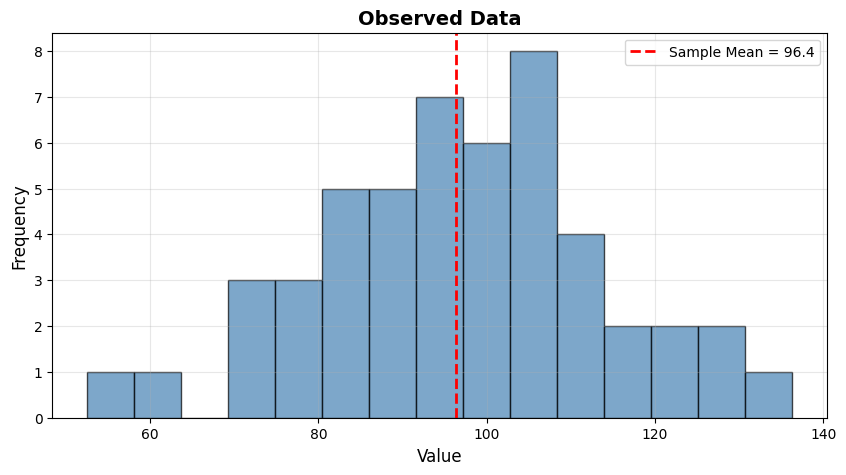

In [2]:
# True parameters (unknown to our inference)
true_mu = 100
true_sigma = 15

# Generate observed data
normal= Normal(true_mu, true_sigma)
observed_data = normal.GenerateRandomValues(50, 42)

# Convert to .NET array
data_array = Array[Double](observed_data)

print(f"Generated {len(observed_data)} observations")
print(f"Sample mean: {np.mean(observed_data):.2f}")
print(f"Sample std: {np.std(observed_data):.2f}")

# Plot data
plt.figure(figsize=(10, 5))
plt.hist(observed_data, bins=15, alpha=0.7, color='steelblue', edgecolor='black')
plt.axvline(np.mean(observed_data), color='red', linestyle='--', linewidth=2, label=f'Sample Mean = {np.mean(observed_data):.1f}')
plt.xlabel('Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Observed Data', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Step 2: Define Priors

We need to specify prior distributions for our parameters. We'll use a weakly informative prior:
- $\mu$ ~ Uniform(50, 150) - we think $\mu$ is somewhere between 50 and 150

**Note:** In Numerics, we need to create a .NET List of distributions. Pay careful attention to how we define our lists below!

In [3]:
mu_prior = Uniform(50, 150)

# Create .NET List of priors
priors = List[IUnivariateDistribution]() # The base interface for distributions in Numerics
priors.Add(mu_prior)

print(f"Prior for mu: Uniform({mu_prior.Minimum}, {mu_prior.Maximum})")
print(f"Prior mean: {mu_prior.Mean:.2f}")

Prior for mu: Uniform(50.0, 150.0)
Prior mean: 100.00


### Step 3: Define the Log-Likelihood Function

The likelihood tells us how probable the data is given parameter values.

For our Normal distribution with known $\sigma$:
```
L($\mu$ | data) = $\prod$ Normal(x | $\mu$, $\sigma$=15)
```

For simplicity, we usually look at the log likelihood to turn the product into a summation.

```
log L($\mu$| data) = $\sum$ log[Normal(x | $\mu$, $\sigma$=15)]
```

**Important:** Numerics expects a log-likelihood function that:
1. Takes a .NET List[Double] of parameters
2. Returns a single double (the log-likelihood)

We must create this function in Python and then convert it to a .NET function before passing it to our sampler.

In [4]:
# Define Python log-likelihood function
def log_likelihood(params):
    dist = Normal(params[0], 15)
    return dist.LogLikelihood(data_array)

# Wrap the Python function as a .NET Func
log_likelihood_func = LogLikelihood(log_likelihood)

print("✓ Log-likelihood function defined")

✓ Log-likelihood function defined


### Step 4: Run the MCMC Sampler

Now we can create and run the RWMH sampler! This is the simplest and most robust MCMC algorithm.

**Mathematical Foundation**
At each iteration, the Metropolis-Hastings algorithm proposes a new state $\theta^*$ from a proposal distribution $q(\theta^* \mid \theta)$ and accepts it with probability:

```math
\alpha(\theta^* \mid \theta) = \min\left(1, \frac{\pi(\theta^*) \cdot q(\theta \mid \theta^*)}{\pi(\theta) \cdot q(\theta^* \mid \theta)}\right)
```

In the RWMH implementation (`RWMH.cs`), the proposal is a symmetric multivariate normal centered at the current state:

```math
\theta^* \sim \mathcal{N}(\theta, \Sigma)
```

Because the proposal is symmetric -- $q(\theta^* \mid \theta) = q(\theta \mid \theta^*)$ -- the proposal densities cancel in the acceptance ratio, simplifying to:

```math
\alpha = \min\left(1, \frac{\pi(\theta^*)}{\pi(\theta)}\right)
```

In log space, which is how the source code computes it:

```math
\log \alpha = \log \pi(\theta^*) - \log \pi(\theta)
```

The proposal is accepted if $\log U \leq \log \alpha$, where $U \sim \text{Uniform}(0,1)$. If any proposed parameter falls outside its prior bounds, the proposal is immediately rejected without evaluating the log-likelihood.

The proposal covariance matrix $\Sigma$ must be provided by the user. A common starting point is a scaled identity matrix, but better performance is achieved when $\Sigma$ approximates the shape of the posterior (e.g., from a preliminary optimization).

**When to use RWMH:**
- General purpose baseline
- Low-dimensional problems (< 10 parameters)
- When simplicity and robustness are priorities
- As a reference for comparing other samplers

In [5]:
# Create RWMH sampler
# RWMH needs a proposal covariance matrix, we give it a blank matrix since we will redefine it in the initialization below
sampler = RWMH(priors, log_likelihood_func, Matrix(1))

# Optional: Configure sampler settings
# sampler.SampleSize = 5000  # Number of samples (default is good)
# sampler.BurnInSamples = 1000  # Burn-in period

# Initialize sampler at the Maximum a Posteriori (MAP) estimate and covariance matrix (optional, can improve convergence)
sampler.Initialize = MCMCSampler.InitializationType.MAP

print("Running MCMC sampler...")
sampler.Sample()
print("✓ Sampling complete")

# Create results object for easy analysis
results = MCMCResults(sampler)

Running MCMC sampler...
✓ Sampling complete


### Step 5: Examine Results

Let's look at the trace plot to check if the chain has converged. Think of this chain as one sample of the final posterior.

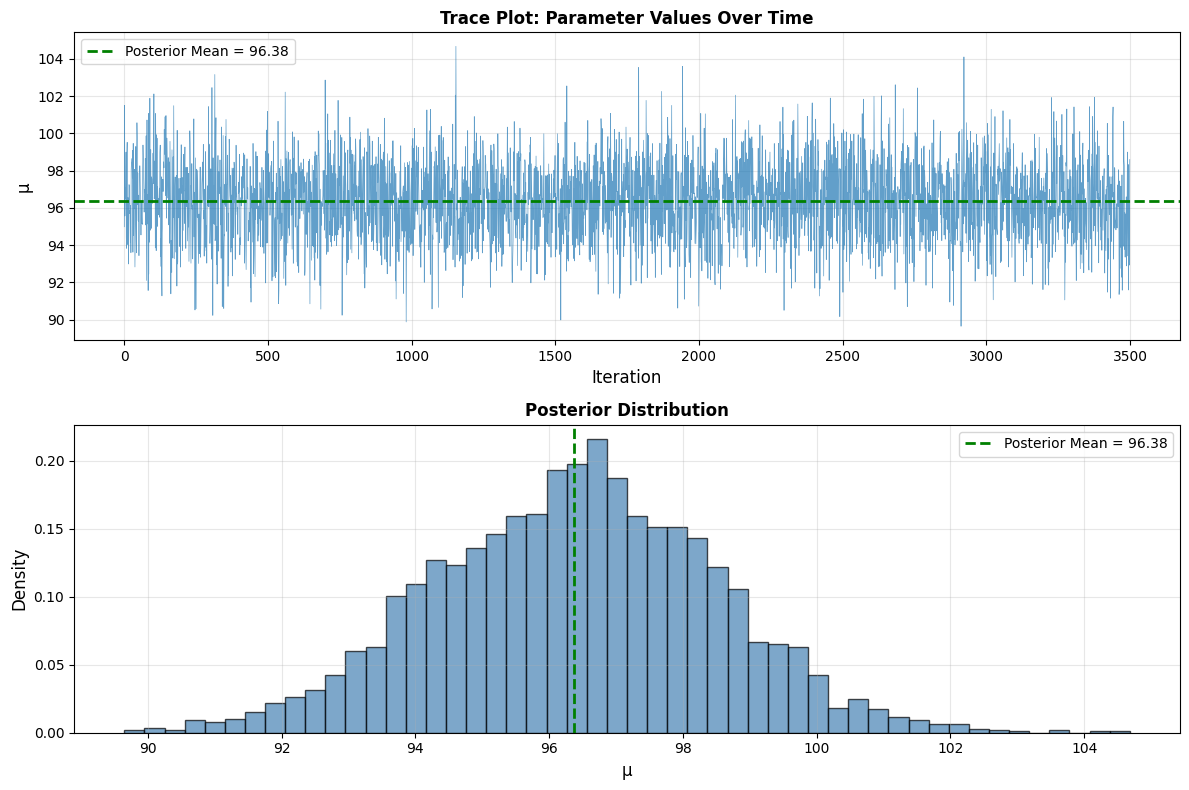

In [6]:
# Extract samples for mu
# MarkovChains[i] = array of ParameterSets
# MarkovChains[i][0] = ParameterSet for first chain
# MarkovChains[i][0].Values[0] = first parameter value (mu)
mu_samples = [results.MarkovChains[0][i].Values[0] for i in range(len(results.MarkovChains[0]))]

# Create trace plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Trace plot
ax1.plot(mu_samples, linewidth=0.5, alpha=0.7)
ax1.axhline(np.mean(mu_samples), color='green', linestyle='--', linewidth=2, label=f'Posterior Mean = {np.mean(mu_samples):.2f}')
ax1.set_xlabel('Iteration', fontsize=12)
ax1.set_ylabel('μ', fontsize=12)
ax1.set_title('Trace Plot: Parameter Values Over Time', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Posterior distribution
ax2.hist(mu_samples, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='black')
ax2.axvline(np.mean(mu_samples), color='green', linestyle='--', linewidth=2, label=f'Posterior Mean = {np.mean(mu_samples):.2f}')
ax2.set_xlabel('μ', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.set_title('Posterior Distribution', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Step 6: Summary Statistics

Numerics provides convenient summary statistics through the MCMCResults object.

In [7]:
# Access summary statistics for parameter 0 (mu)
param_results = results.ParameterResults[0]
summary = param_results.SummaryStatistics

summary_table = pd.DataFrame({
    'Metric': ['Posterior mean','Posterior std dev','Posterior median','5th percentile','95th percentile','90% credible interval','True value','Observed sample mean'],
    'Value': [
        f"{summary.Mean:.4f}",
        f"{summary.StandardDeviation:.4f}",
        f"{summary.Median:.4f}",
        f"{summary.LowerCI:.4f}",
        f"{summary.UpperCI:.4f}",
        f"[{summary.LowerCI:.2f}, {summary.UpperCI:.2f}]",
        f"{true_mu:.4f}",
        f"{np.mean(observed_data):.4f}",
    ]
})

print("POSTERIOR SUMMARY STATISTICS FOR μ")
display(summary_table)


POSTERIOR SUMMARY STATISTICS FOR μ


,Metric,Value
0,Posterior mean,96.3782
1,Posterior std dev,2.1320
2,Posterior median,96.3422
3,5th percentile,92.9017
4,95th percentile,99.9107
5,90% credible interval,"[92.90, 99.91]"
6,True value,100.0000
7,Observed sample mean,96.3985


## Example 2: Estimating Both Mean and Variance

Now let's estimate **both** $\mu$ and $\sigma$ when both are unknown.

In [8]:
# Create priors for both parameters
mu_prior = Uniform(50, 150)
sigma_prior = Uniform(1, 50)

priors_both = List[IUnivariateDistribution]()
priors_both.Add(mu_prior)
priors_both.Add(sigma_prior)

# New log-likelihood function for both parameters
def log_likelihood_both(params):
    dist = Normal(params[0], params[1])
    return dist.LogLikelihood(data_array)

# Wrap the Python function as a .NET Func
log_likelihood_both_func = LogLikelihood(log_likelihood_both)

# Run sampler
print("Running MCMC for both parameters...")
# RWMH needs a proposal covariance matrix, we give it a blank matrix since we will redefine it in the initialization below
sampler_both = RWMH(priors_both, log_likelihood_both_func, Matrix(2))
sampler_both.Initialize = MCMCSampler.InitializationType.MAP
sampler_both.Sample()
results_both = MCMCResults(sampler_both)
print("✓ Sampling complete")

Running MCMC for both parameters...
✓ Sampling complete


### Analyze Two-Parameter Results
Recall our true $\mu$ is 100 and our true $\sigma$ is 15.

c:\GIT\Numerics-Python-Examples\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 120590 (\N{MATHEMATICAL ITALIC SMALL SIGMA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


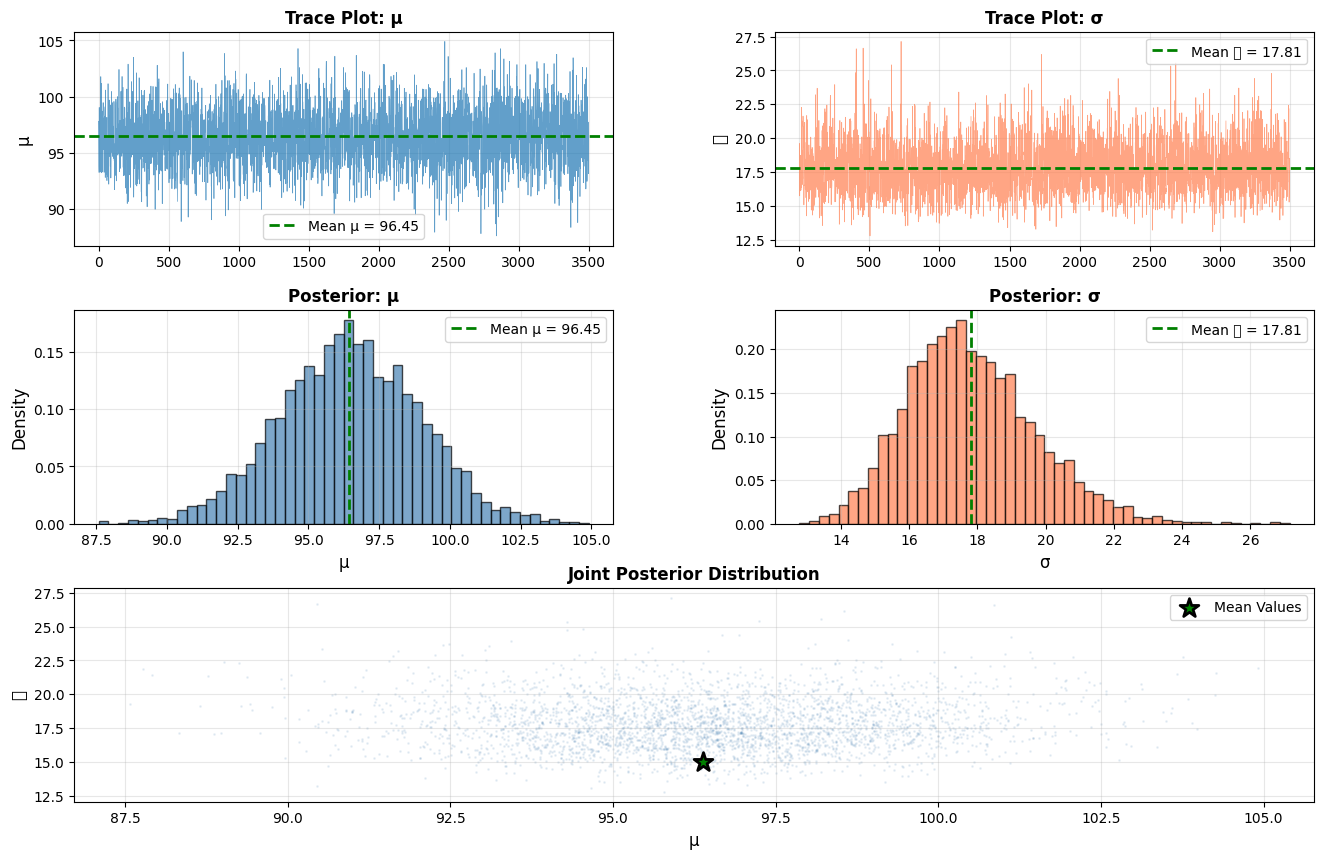


Posterior Summary:


,Parameter,True,Posterior Mean,5%,95%
0,μ,100,96.409,92.251,100.539
1,σ,15,17.741,14.986,21.069


In [9]:
# Extract samples
mu_samples_2 = [results_both.MarkovChains[0][i].Values[0] for i in range(len(results_both.MarkovChains[0]))]
# For sigma we only need to change Values index to 1 instead of 0
sigma_samples_2 = [results_both.MarkovChains[0][i].Values[1] for i in range(len(results_both.MarkovChains[0]))]

# Create figure with multiple subplots
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# Trace plots
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(mu_samples_2, linewidth=0.5, alpha=0.7)
ax1.axhline(np.mean(mu_samples_2), color='green', linestyle='--', linewidth=2, label=f'Mean μ = {np.mean(mu_samples_2):.2f}')
ax1.set_ylabel('μ', fontsize=12)
ax1.set_title('Trace Plot: μ', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(sigma_samples_2, linewidth=0.5, alpha=0.7, color='coral')
ax2.axhline(np.mean(sigma_samples_2), color='green', linestyle='--', linewidth=2, label=f'Mean 𝜎 = {np.mean(sigma_samples_2):.2f}')
ax2.set_ylabel('𝜎', fontsize=12)
ax2.set_title('Trace Plot: σ', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Posterior distributions
ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(mu_samples_2, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='black')
ax3.axvline(np.mean(mu_samples_2), color='green', linestyle='--', linewidth=2, label=f'Mean μ = {np.mean(mu_samples_2):.2f}')
ax3.set_xlabel('μ', fontsize=12)
ax3.set_ylabel('Density', fontsize=12)
ax3.set_title('Posterior: μ', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

ax4 = fig.add_subplot(gs[1, 1])
ax4.hist(sigma_samples_2, bins=50, density=True, alpha=0.7, color='coral', edgecolor='black')
ax4.axvline(np.mean(sigma_samples_2), color='green', linestyle='--', linewidth=2, label=f'Mean 𝜎 = {np.mean(sigma_samples_2):.2f}')
ax4.set_xlabel('σ', fontsize=12)
ax4.set_ylabel('Density', fontsize=12)
ax4.set_title('Posterior: σ', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

# Joint posterior (scatter plot)
ax5 = fig.add_subplot(gs[2, :])
ax5.scatter(mu_samples_2, sigma_samples_2, alpha=0.1, s=1, color='steelblue')
ax5.scatter(np.mean(mu_samples), np.mean(true_sigma), color='green', s=200, marker='*', edgecolor='black', linewidth=2, label='Mean Values', zorder=5)
ax5.set_xlabel('μ', fontsize=12)
ax5.set_ylabel('𝜎', fontsize=12)
ax5.set_title('Joint Posterior Distribution', fontsize=12, fontweight='bold')
ax5.legend()
ax5.grid(True, alpha=0.3)

plt.show()

summary_rows = []
for label, true_val, idx in [('μ', true_mu, 0), ('σ', true_sigma, 1)]:
    s = results_both.ParameterResults[idx].SummaryStatistics
    summary_rows.append({'Parameter': label, 'True': true_val, 'Posterior Mean': s.Mean, '5%': s.LowerCI, '95%': s.UpperCI})

posterior_summary = pd.DataFrame(summary_rows)
print("\nPosterior Summary:")
display(posterior_summary.round(3))


## Understanding Burn-in and Thinning

### Burn-in (Warmup)
Burn in considers the initial samples before the chain converges. Sometimes it can take a while for the chain to explore the posterior space and converge, so these initial samples can be seemingly random and misleading and should be discarded. This allows chains to reach stationary.

**Warmup guidelines:**
- RWMH: 2000-5000 iterations
- ARWMH: 2000-3000 (adapts during warmup)
- DEMCz: 1500-3000 (converges faster)
- HMC: 1000-2000 (efficient exploration)
- NUTS: 1000-2000 (step size adapts during warmup)
- Rule of thumb: Warmup ≥ 50% of main iterations

### Thinning
Taking every nth sample to reduce autocorrelation.  

**Thinning trade-offs:**
- Reduces autocorrelation in final samples
- Saves memory for long runs
- Doesn't improve efficiency (better to run longer without thinning)
- Rule of thumb: Keep thinning interval ≤ autocorrelation length

**Note:** Numerics applies thinning by default, so MarkovChains already reflect the thinning interval. If you compare to Python libraries, either thin the Python chain to match or set Numerics ThinningInterval to 1.

Let's visualize these concepts:

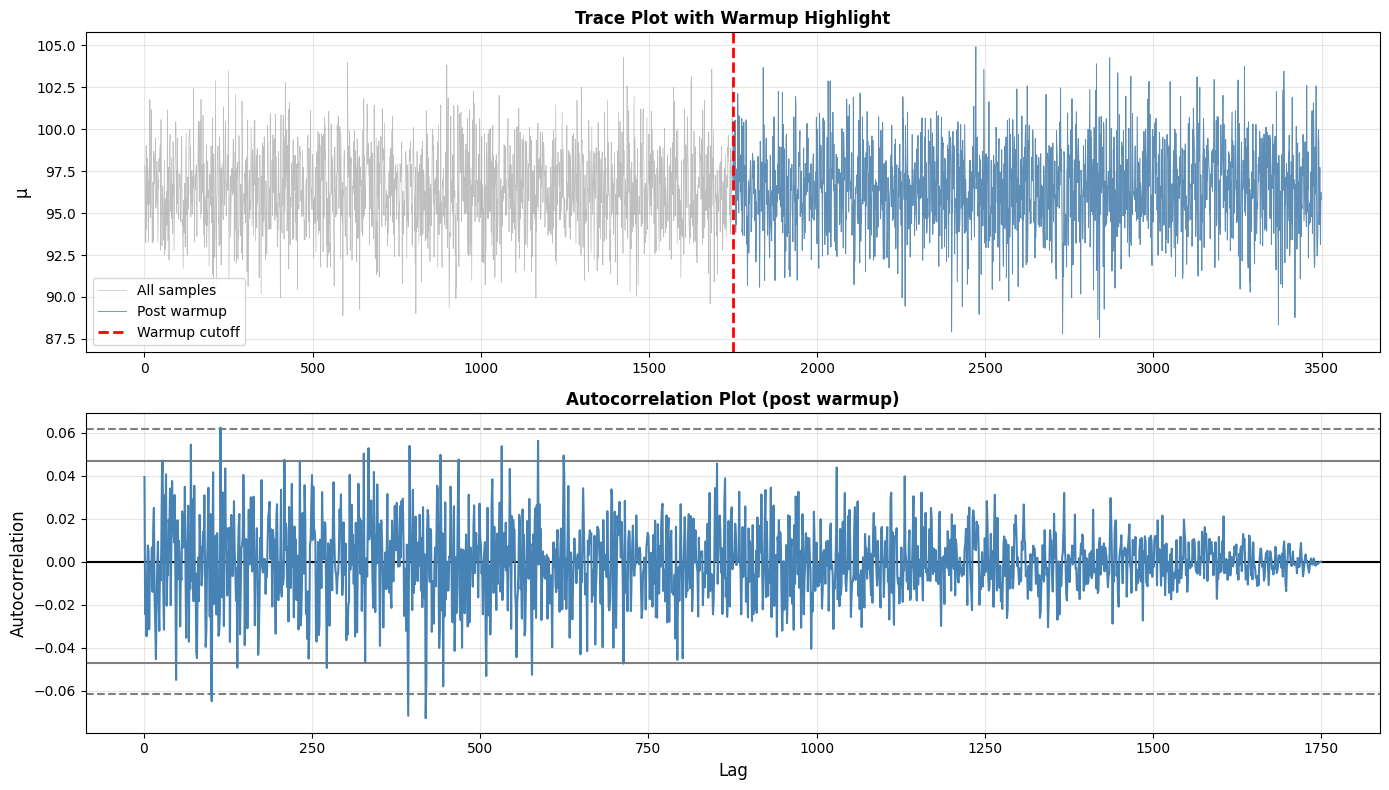

Warmup iterations (Numerics setting): 1750
Thinning interval (Numerics setting): 20
Effective samples shown after warmup: 1750
Acceptance rate: 0.44
Acceptance rate matters because very low rates indicate poor exploration, while very high rates often indicate tiny steps.


In [10]:
# Numerics exposes warmup and thinning settings directly on the sampler.
burn_in = sampler_both.WarmupIterations
thinning = sampler_both.ThinningInterval

if burn_in >= len(mu_samples_2):
    burn_in = max(len(mu_samples_2) - 1, 0)

post_burn_samples = mu_samples_2[burn_in:]

# Plot with warmup highlighted
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
ax1.plot(mu_samples_2, linewidth=0.5, alpha=0.5, color='gray', label='All samples')
if burn_in > 0:
    ax1.plot(range(burn_in, len(mu_samples_2)), post_burn_samples, linewidth=0.7, alpha=0.8, color='steelblue', label='Post warmup')
    ax1.axvline(burn_in, color='red', linestyle='--', linewidth=2, label='Warmup cutoff')
ax1.set_ylabel('μ', fontsize=12)
ax1.set_title('Trace Plot with Warmup Highlight', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

mu_series = pd.Series(post_burn_samples if len(post_burn_samples) > 1 else mu_samples_2)
pd.plotting.autocorrelation_plot(mu_series, ax=ax2, color='steelblue')
ax2.set_xlabel('Lag', fontsize=12)
ax2.set_ylabel('Autocorrelation', fontsize=12)
ax2.set_title('Autocorrelation Plot (post warmup)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

acceptance_rate = sampler_both.AcceptanceRates[0]
print(f"Warmup iterations (Numerics setting): {sampler_both.WarmupIterations}")
print(f"Thinning interval (Numerics setting): {thinning}")
print(f"Effective samples shown after warmup: {len(post_burn_samples)}")
print(f"Acceptance rate: {acceptance_rate:.2f}")
print("Acceptance rate matters because very low rates indicate poor exploration, while very high rates often indicate tiny steps.")


## Summary
In this notebook you:

$\checkmark$ Built Bayesian models for Normal data with unknown $\mu$, then unknown ($\mu$, $\sigma$).       
$\checkmark$ Defined priors and custom log-likelihood functions for Numerics MCMC samplers.       
$\checkmark$ Ran RWMH, visualized trace/posterior/joint distributions, and interpreted credible intervals.        
$\checkmark$ Reviewed sampler diagnostics including acceptance rate and autocorrelation.      

Key takeaway: MCMC gives full uncertainty quantification for parameters, not only point estimates.

## Next Steps
- **04_mcmc_bayesian_inference.ipynb**: Real-world Bayesian workflows and model comparison.
- **05_mcmc_advanced.ipynb**: Multiple chains, R-hat, ESS, and advanced samplers.

## Exercise
1. Change the prior range for $\mu$ and re-run the sampler.
2. Compare posterior mean and credible interval to the true $\mu$.
3. Increase sample size and observe mixing/ESS changes.
